# 🔐 AI Cybersecurity Chatbot using ML, RAG & LLM

## Introduction

In this project, I built an AI-based cybersecurity chatbot that can detect suspicious network activities and explain them in a simple way.

The main idea is to combine Machine Learning for attack detection with RAG (Retrieval-Augmented Generation) and LLMs to provide intelligent explanations and cybersecurity recommendations.

This project aims to make cybersecurity analysis easier and more interactive.

## Environment Setup

Before starting, I installed all the necessary libraries required for machine learning, embeddings, vector database management, and chatbot deployment.

In [1]:
!pip install langchain langchain-community langchain-huggingface chromadb sentence-transformers unstructured -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.41.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.41.1 which is incompatible.
gradio 5.50.0 requires aiofiles<25.0,>=22.0, but you have aiofiles 25.1.0 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.13.3 which is incompatible.


In [2]:
!pip install gradio

  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached pydantic-2.12.3-py3-none-any.whl.metadata (87 kB)
  Using cached pydantic_core-2.41.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached aiofiles-24.1.0-py3-none-any.whl (15 kB)
Using cached pydantic-2.12.3-py3-none-any.whl (462 kB)
Using cached pydantic_core-2.41.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.1 MB)
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.46.3
    Uninstalling pydantic_core-2.46.3:
      Successfully uninstalled pydantic_core-2.46.3
  Attempting uninstall: aiofiles
    Found existing installation: aiofiles 25.1.0
    Uninstalling aiofiles-25.1.0:
      Successfully uninstalled aiofiles-25.1.0
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.13.3
    Uninstalling pydantic-2.13.3:
      Successfully uninstalled pydantic-2.13.3
ERROR: pip's dependency resolver does

## Importing Libraries

Here, I import the main libraries that will be used throughout the project for data processing, model training, and building the chatbot.

In [3]:
import pandas as pd
import numpy as np
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Loading the Dataset

For this project, I used the NSL-KDD dataset, which is a well-known dataset for intrusion detection and cybersecurity analysis.

In [4]:
import zipfile

with zipfile.ZipFile("archive (3).zip", 'r') as zip_ref:
    zip_ref.extractall("data")
import os

os.listdir("data")

train_df = pd.read_csv("data/KDDTrain+.txt", header=None)
test_df = pd.read_csv("data/KDDTest+.txt", header=None)
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Preparing the Dataset

After loading the dataset, I organized the columns and prepared the data structure to make it easier to process.

In [5]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root",
"num_file_creations","num_shells","num_access_files","num_outbound_cmds",
"is_host_login","is_guest_login","count","srv_count","serror_rate",
"srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
"diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_df.columns = columns
test_df.columns = columns

## Preparing the Target Labels

The original dataset contains many attack types, so I converted them into binary classes:

- Normal traffic → 0  
- Attack traffic → 1

This simplifies the detection task.

In [6]:
train_df['binary_label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['binary_label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

## Separating Features and Labels

At this step, I separated the input data (features) from the target labels to prepare them for training.

In [7]:
X_train = train_df.drop(columns=['label', 'binary_label'])
y_train = train_df['binary_label']

X_test = test_df.drop(columns=['label', 'binary_label'])
y_test = test_df['binary_label']

## Encoding Categorical Data

Some features are categorical, so I transformed them into numerical values using one-hot encoding because machine learning models work better with numerical data.

In [8]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## First Model: Isolation Forest

I started with Isolation Forest because it is useful for anomaly detection and can identify unusual patterns in network traffic.

In [9]:

iso_model = IsolationForest(contamination=0.1, random_state=42)
iso_model.fit(X_train)

iso_pred = iso_model.predict(X_test)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

## Evaluating Isolation Forest

After training the model, I evaluated its performance to see how well it detects attacks.

In [10]:

print(classification_report(y_test, iso_pred))

              precision    recall  f1-score   support

           0       0.50      0.98      0.66      9711
           1       0.95      0.26      0.41     12833

    accuracy                           0.57     22544
   macro avg       0.73      0.62      0.53     22544
weighted avg       0.76      0.57      0.52     22544



## Second Model: Random Forest

Then I trained a Random Forest classifier to compare its performance with Isolation Forest and check which model performs better.

In [11]:


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

## Evaluating Random Forest

Here, I measured the performance of Random Forest using classification metrics.

In [12]:

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



## Comparing Both Models

At this stage, I compared both models to determine which one gives better results for attack detection.

In [13]:


comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Random Forest"],
    "Accuracy": [0.57, 0.80],
    "Recall (Attack)": [0.26, 0.67],
    "Precision (Attack)": [0.95, 0.97]
})

comparison

,Model,Accuracy,Recall (Attack),Precision (Attack)
0,Isolation Forest,0.57,0.26,0.95
1,Random Forest,0.80,0.67,0.97


## Visualizing the Results

To make the comparison clearer, I created visualizations to show the performance difference between the models.

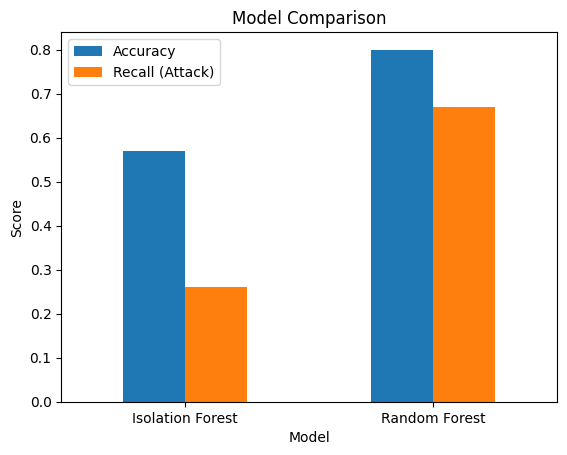

In [14]:

comparison.set_index("Model")[["Accuracy", "Recall (Attack)"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Choosing the Final Model

Based on the evaluation results, Random Forest performed better than Isolation Forest.

That is why I selected it as the main detection model for the chatbot.

## Building the Knowledge Base

To make the chatbot smarter, I created a small cybersecurity knowledge base containing information about different attack types and security practices.

In [15]:


docs = [
    Document(page_content="Neptune attack is a SYN flood that overwhelms a server with connection requests.", metadata={"label": "neptune"}),
    Document(page_content="Smurf attack floods a network using ICMP echo requests.", metadata={"label": "smurf"}),
    Document(page_content="Portsweep scans ports to find open vulnerabilities.", metadata={"label": "portsweep"}),
    Document(page_content="Ipsweep scans multiple IPs to detect active hosts.", metadata={"label": "ipsweep"}),
    Document(page_content="Normal traffic represents legitimate network activity.", metadata={"label": "normal"})
]

## Creating Embeddings and Storing Knowledge

To enable semantic search, I converted the knowledge base into embeddings and stored them inside a vector database.

This allows the chatbot to retrieve relevant information before generating responses.

In [16]:

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vector_db = Chroma.from_documents(docs, embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Testing Information Retrieval

Before connecting everything together, I tested the retrieval system to verify that relevant cybersecurity information can be found correctly.

In [17]:
query = "syn flood attack"

results = vector_db.similarity_search(query, k=2)

for r in results:
    print(r.page_content)

Neptune attack is a SYN flood that overwhelms a server with connection requests.
Smurf attack floods a network using ICMP echo requests.


## Testing the Detection Model

At this step, I tested the selected machine learning model on sample data to verify its predictions.

In [18]:
sample = X_test.iloc[0:1]

pred = rf_model.predict(sample)[0]
label = test_df.iloc[0]['label']

## Integrating the Language Model

To generate explanations and recommendations, I connected a transformer-based language model to the system.

In [19]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="google/flan-t5-base"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

## Building the RAG Pipeline

Here, I combined machine learning predictions with retrieved cybersecurity knowledge and the language model to generate intelligent answers.

This is the main core of the project.

In [20]:
def rag_system(pred, label):

    # 1. retrieve knowledge
    docs_found = vector_db.similarity_search(label, k=1)
    context = docs_found[0].page_content

    # 2. prompt
    prompt = f"""
You are a cybersecurity expert.

Attack type: {label}
Prediction: {pred}

Context:
{context}

Explain clearly:
- What is it?
- Risk level
- Recommendation
"""

    # 3. generate answer
    result = llm(
    prompt,
    max_new_tokens=120,
    do_sample=False,
    truncation=True
)[0]["generated_text"]

    return result

## Testing the Full Pipeline

After building the complete pipeline, I tested it to make sure all parts work together correctly.

In [21]:
for i in range(3):
    sample = X_test.iloc[i:i+1]

    pred = rf_model.predict(sample)[0]
    label = test_df.iloc[i]['label']

    print(rag_system(pred, label))
    print("="*50)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a cybersecurity expert.

Attack type: neptune
Prediction: 1

Context:
Neptune attack is a SYN flood that overwhelms a server with connection requests.

Explain clearly:
- What is it?
- Risk level
- Recommendation



Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a cybersecurity expert.

Attack type: neptune
Prediction: 1

Context:
Neptune attack is a SYN flood that overwhelms a server with connection requests.

Explain clearly:
- What is it?
- Risk level
- Recommendation



Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a cybersecurity expert.

Attack type: normal
Prediction: 0

Context:
Normal traffic represents legitimate network activity.

Explain clearly:
- What is it?
- Risk level
- Recommendation



## Creating the Chatbot Logic

This part handles user interaction and connects user questions to the detection and explanation pipeline.

In [22]:
def chatbot(query):

    docs = vector_db.similarity_search(query,k=1)

    if not docs:
        return "Attack not found."

    context = docs[0].page_content

    prompt=f"""
You are a cybersecurity expert.

User query: {query}

Context:
{context}

Explain:
- Description
- Risk
- Recommendation
"""

    result=llm(
        prompt,
        max_new_tokens=120,
        do_sample=False
    )[0]["generated_text"]

    return result

## Testing in Terminal

Before building the web interface, I tested the chatbot in terminal mode to verify its functionality.

In [24]:
print("💬 Cybersecurity Chatbot is ready (type 'exit' to stop)")

while True:
    query = input("You: ")

    if query.lower() == "exit":
        break

    print("\nBot:", chatbot(query))
    print("-"*50)

💬 Cybersecurity Chatbot is ready (type 'exit' to stop)
You: neptune


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Bot: 
You are a cybersecurity expert.

User query: neptune

Context:
Neptune attack is a SYN flood that overwhelms a server with connection requests.

Explain:
- Description
- Risk
- Recommendation

--------------------------------------------------
You: exit


## Deploying the Web Interface

Finally, I created a web interface using Gradio to make the chatbot easier to use and more interactive.

In [25]:
import gradio as gr

def respond(message):
    return chatbot(message)

demo = gr.Interface(
    fn=respond,
    inputs=gr.Textbox(lines=2, placeholder="Type your question about cyber attacks..."),
    outputs="text",
    title="🔐 Cybersecurity RAG Chatbot",
    description="Ask about network attacks and get AI explanations using ML + RAG + LLM",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c555bd2e13743484d5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

Through this project, I learned how to combine Machine Learning, RAG, and LLMs in one complete system.

This project helped me understand how AI can be used in cybersecurity to detect attacks and provide useful explanations.

In the future, I would like to improve the knowledge base and make the chatbot more accurate and powerful.